#### In this step, we import the necessary Python libraries required for data manipulation and analysis.
#### Pandas is used for handling tabular data, while NumPy is used for numerical operations.

In [22]:
import pandas as pd
import numpy as np

#### The dataset is loaded into a Pandas DataFrame for further processing.
#### This allows us to perform structured data analysis efficiently.

In [23]:
df = pd.read_csv("wb_all_districts_raw_data - Combined_Data.csv")  
df.head()

,District,Year,Government,Private,Total,Retention_Rate,Madhyamik_Pass_Percentage,HS_Pass_Percentage,Literacy_Rate,Girls_Percentage,Performance_Index
0,ALIPURDUAR,2018,261848,57300,322643,0.24,71.3,74.0,73.0,50.34,72.72
1,ALIPURDUAR,2019,252773,64328,320447,0.35,72.5,77.4,73.0,49.99,74.56
2,ALIPURDUAR,2020,250810,72961,324336,0.35,73.8,81.0,73.0,49.88,76.52
3,BANKURA,2018,698436,47690,754032,0.27,78.6,78.3,70.3,48.72,76.82
4,BANKURA,2019,685926,53910,747701,0.37,79.7,81.4,70.3,48.84,78.50


#### Before cleaning, it is important to understand the structure of the dataset.
#### This includes checking the number of rows and columns, data types, and summary statistics.

In [24]:
df.shape

(69, 11)

In [25]:
df.columns

Index(['District', 'Year', 'Government', 'Private', 'Total', 'Retention_Rate',
       'Madhyamik_Pass_Percentage', 'HS_Pass_Percentage', 'Literacy_Rate',
       'Girls_Percentage', 'Performance_Index'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   District                   69 non-null     object 
 1   Year                       69 non-null     int64  
 2   Government                 69 non-null     int64  
 3   Private                    69 non-null     int64  
 4   Total                      69 non-null     int64  
 5   Retention_Rate             69 non-null     float64
 6   Madhyamik_Pass_Percentage  69 non-null     float64
 7   HS_Pass_Percentage         69 non-null     float64
 8   Literacy_Rate              69 non-null     float64
 9   Girls_Percentage           69 non-null     float64
 10  Performance_Index          69 non-null     float64
dtypes: float64(6), int64(4), object(1)
memory usage: 6.1+ KB


In [27]:
df.describe()

,Year,Government,Private,Total,Retention_Rate,Madhyamik_Pass_Percentage,HS_Pass_Percentage,Literacy_Rate,Girls_Percentage,Performance_Index
count,69.000000,6.900000e+01,69.000000,6.900000e+01,69.000000,69.000000,69.000000,69.000000,69.000000,69.000000
mean,2019.000000,6.716882e+05,90493.086957,7.901862e+05,0.320725,83.210145,84.294203,74.939130,50.410435,81.989565
std,0.822478,3.935768e+05,66458.241823,4.638985e+05,0.073291,7.552934,5.656201,7.291377,1.219988,6.256625
min,2018.000000,3.805200e+04,4208.000000,4.345700e+04,0.170000,67.100000,72.500000,59.100000,48.290000,68.900000
25%,2018.000000,4.014940e+05,47690.000000,5.012820e+05,0.270000,78.400000,80.000000,70.700000,49.620000,77.180000
50%,2019.000000,6.805710e+05,72961.000000,7.540320e+05,0.330000,82.200000,84.600000,75.000000,50.230000,81.020000
75%,2020.000000,8.713250e+05,116356.000000,9.948580e+05,0.370000,89.600000,88.600000,79.900000,51.410000,87.360000
max,2020.000000,1.638038e+06,267752.000000,1.905241e+06,0.520000,96.600000,96.200000,87.000000,53.120000,94.520000


#### Column names are standardized to remove unnecessary spaces and ensure consistency. This helps avoid errors during analysis and improves readability.

In [28]:
df.columns = df.columns.str.strip()

In [29]:
df.columns

Index(['District', 'Year', 'Government', 'Private', 'Total', 'Retention_Rate',
       'Madhyamik_Pass_Percentage', 'HS_Pass_Percentage', 'Literacy_Rate',
       'Girls_Percentage', 'Performance_Index'],
      dtype='object')

#### Some columns may be incorrectly stored as text. These are converted into numeric format to enable mathematical operations and analysis.

In [30]:
numeric_cols = [
    'Government', 'Private', 'Total',
    'Retention_Rate',
    'Madhyamik_Pass_Percentage',
    'HS_Pass_Percentage',
    'Literacy_Rate',
    'Girls_Percentage',
    'Performance_Index'
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

#### Missing values can affect analysis and model performance. Therefore, we check for null values and replace them using the mean of the column.

In [31]:
df.isnull().sum()

District                     0
Year                         0
Government                   0
Private                      0
Total                        0
Retention_Rate               0
Madhyamik_Pass_Percentage    0
HS_Pass_Percentage           0
Literacy_Rate                0
Girls_Percentage             0
Performance_Index            0
dtype: int64

In [32]:
df.fillna(df.mean(numeric_only=True), inplace=True)

#### The total number of institutions should ideally match the sum of government and private institutions. We verify this relationship and calculate any differences.

In [33]:
df['Calculated_Total'] = df['Government'] + df['Private']

df[['Total', 'Calculated_Total']].head()

,Total,Calculated_Total
0,322643,319148
1,320447,317101
2,324336,323771
3,754032,746126
4,747701,739836


In [34]:
df['Total_Difference'] = df['Total'] - (df['Government'] + df['Private'])

In [35]:
df['Total_Difference'].describe()

count        69.000000
mean      28004.884058
std       37671.830079
min           0.000000
25%        3450.000000
50%       16014.000000
75%       33870.000000
max      185781.000000
Name: Total_Difference, dtype: float64

#### Since the total does not exactly match the sum of government and private institutions,a new feature called "Other_Institutions" is created to capture the remaining values. This improves the completeness of the dataset.

In [43]:
df['Other_Institutions'] = df['Total'] - (df['Government'] + df['Private'])

#### District names are converted to uppercase and stripped of extra spaces to ensure uniformity and avoid duplication issues.

In [37]:
df['District'] = df['District'].str.upper().str.strip()

#### The dataset is sorted by district and year to maintain chronological order. This is important for time-based analysis.

In [38]:
df = df.sort_values(by=['District', 'Year']).reset_index(drop=True)

#### A unique identifier is created by combining district name and year. This ensures each row can be uniquely identified.

In [44]:
df['ID'] = df['District'] + "_" + df['Year'].astype(str)

#### A final inspection is performed to ensure that the dataset is clean, structured, and ready for further analysis.

In [45]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   District                   69 non-null     object 
 1   Year                       69 non-null     int64  
 2   Government                 69 non-null     int64  
 3   Private                    69 non-null     int64  
 4   Total                      69 non-null     int64  
 5   Retention_Rate             69 non-null     float64
 6   Madhyamik_Pass_Percentage  69 non-null     float64
 7   HS_Pass_Percentage         69 non-null     float64
 8   Literacy_Rate              69 non-null     float64
 9   Girls_Percentage           69 non-null     float64
 10  Performance_Index          69 non-null     float64
 11  Calculated_Total           69 non-null     int64  
 12  Total_Difference           69 non-null     int64  
 13  Other_Institutions         69 non-null     int64  
 

#### The cleaned dataset is saved for future use in analysis and modeling.

In [40]:
df.to_csv("wb_education_cleaned.csv", index=False)

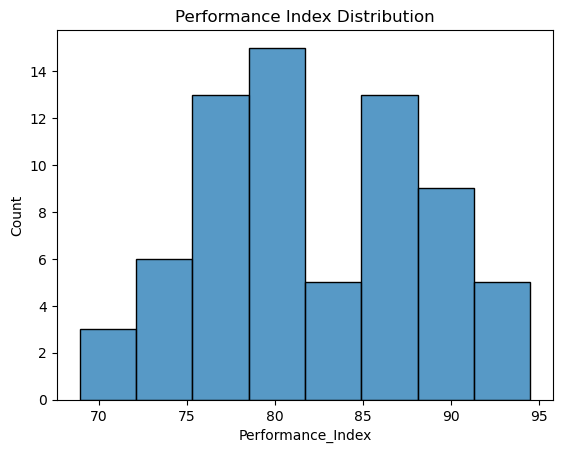

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['Performance_Index'])
plt.title("Performance Index Distribution")
plt.show()

## Feature engineering involves creating new variables from existing data to improve analysis and model performance. In this project, new metrics such as growth rates, performance g

#### Growth rates help measure improvement or decline in performance over time for each district.

In [46]:
df = df.sort_values(by=['District', 'Year'])

df['Madhyamik_Growth_%'] = df.groupby('District')['Madhyamik_Pass_Percentage'].pct_change() * 100
df['HS_Growth_%'] = df.groupby('District')['HS_Pass_Percentage'].pct_change() * 100

#### The pct_change() function calculates the percentage change year-over-year for each district.

#### Performance gaps highlight differences between various indicators and help identify inconsistencies.

In [47]:
df['HS_Madhyamik_Gap'] = df['HS_Pass_Percentage'] - df['Madhyamik_Pass_Percentage']
df['Literacy_Madhyamik_Gap'] = df['Literacy_Rate'] - df['Madhyamik_Pass_Percentage']

#### These features help analyze whether higher literacy translates into better exam performance.

#### Efficiency metrics evaluate how effectively districts convert resources into performance outcomes.

In [48]:
df['Performance_per_Student'] = df['Performance_Index'] / df['Total']

#### This metric normalizes performance relative to the size of institutions.

## Gender distribution may influence educational outcomes. This feature measures deviation from a balanced gender ratio (50%).

In [49]:
df['Gender_Deviation'] = df['Girls_Percentage'] - 50

#### A value close to zero indicates a balanced gender distribution.

#### A composite score is created by combining multiple indicators to represent overall district performance.

In [50]:
df['Composite_Score'] = (
    0.4 * df['Madhyamik_Pass_Percentage'] +
    0.4 * df['HS_Pass_Percentage'] +
    0.2 * df['Literacy_Rate']
)

#### Weighted scoring gives more importance to examination performance while still considering literacy.

#### Growth rates produce missing values for the first year of each district. These are replaced with zero.

In [51]:
df.fillna(0, inplace=True)

#### The dataset is reviewed after feature engineering to ensure all new variables are correctly created.

In [52]:
df.head()
df.columns

Index(['District', 'Year', 'Government', 'Private', 'Total', 'Retention_Rate',
       'Madhyamik_Pass_Percentage', 'HS_Pass_Percentage', 'Literacy_Rate',
       'Girls_Percentage', 'Performance_Index', 'Calculated_Total',
       'Total_Difference', 'Other_Institutions', 'ID', 'Madhyamik_Growth_%',
       'HS_Growth_%', 'HS_Madhyamik_Gap', 'Literacy_Madhyamik_Gap',
       'Performance_per_Student', 'Gender_Deviation', 'Composite_Score'],
      dtype='object')

#### The dataset with engineered features is saved for further analysis and modeling.

In [53]:
df.to_csv("wb_education_featured.csv", index=False)

## Exploratory Data Analysis (EDA) is performed to understand the distribution, trends, and relationships among variables. It helps in identifying patterns and generating insights for decision-making.

#### This visualization shows how the performance index is distributed across districts.

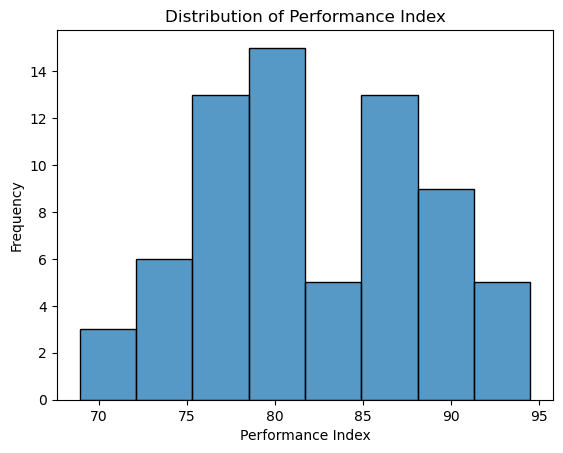

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['Performance_Index'])
plt.title("Distribution of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Frequency")
plt.show()

#### This analysis shows how performance has changed over time.

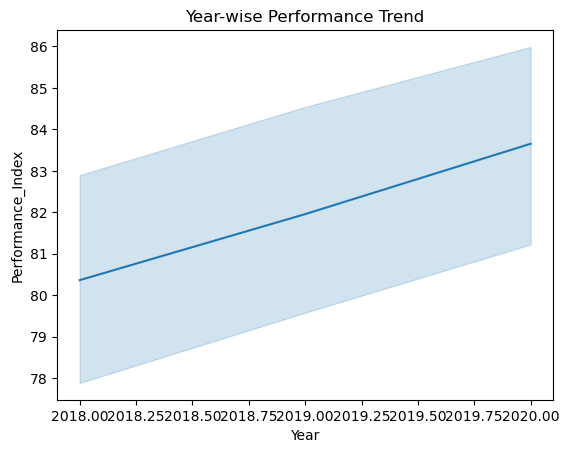

In [55]:
plt.figure()
sns.lineplot(data=df, x='Year', y='Performance_Index')
plt.title("Year-wise Performance Trend")
plt.show()

#### Identifying top-performing districts helps in understanding best practices.

In [56]:
top_districts = df.groupby('District')['Performance_Index'].mean().sort_values(ascending=False).head(5)
top_districts

District
PURBA MEDINIPUR      93.320000
KALIMPONG            91.320000
KOLKATA              89.500000
NORTH 24 PARGANAS    88.500000
PASCHIM MEDINIPUR    87.586667
Name: Performance_Index, dtype: float64

#### This identifies districts that may require policy attention.

In [57]:
bottom_districts = df.groupby('District')['Performance_Index'].mean().sort_values().head(5)
bottom_districts

District
UTTAR DINAJPUR      70.780000
JALPAIGURI          72.360000
ALIPURDUAR          74.600000
DAKSHIN DINAJPUR    76.933333
PURULIA             77.206667
Name: Performance_Index, dtype: float64

#### Correlation analysis helps identify relationships between variables.

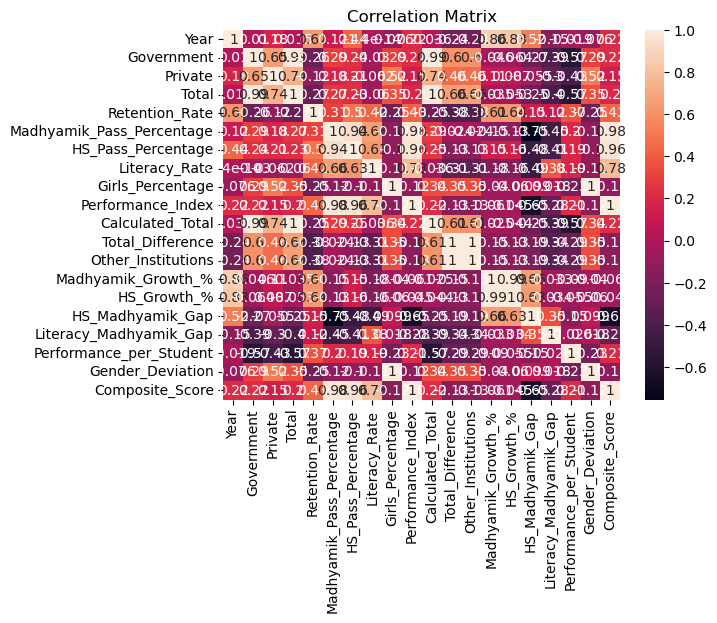

In [58]:
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

#### This plot shows whether higher retention leads to better performance.

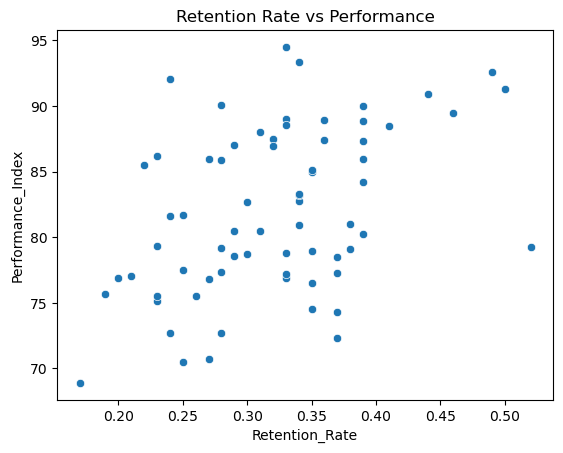

In [59]:
plt.figure()
sns.scatterplot(data=df, x='Retention_Rate', y='Performance_Index')
plt.title("Retention Rate vs Performance")
plt.show()

#### This analysis explores the relationship between gender distribution and performance.

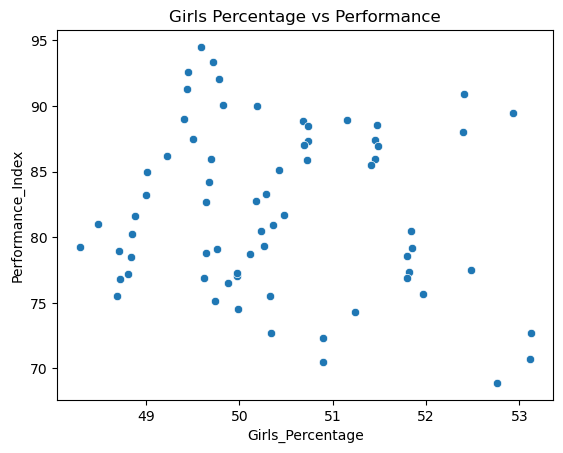

In [60]:
plt.figure()
sns.scatterplot(data=df, x='Girls_Percentage', y='Performance_Index')
plt.title("Girls Percentage vs Performance")
plt.show()

#### This visualization compares performance trends across districts.

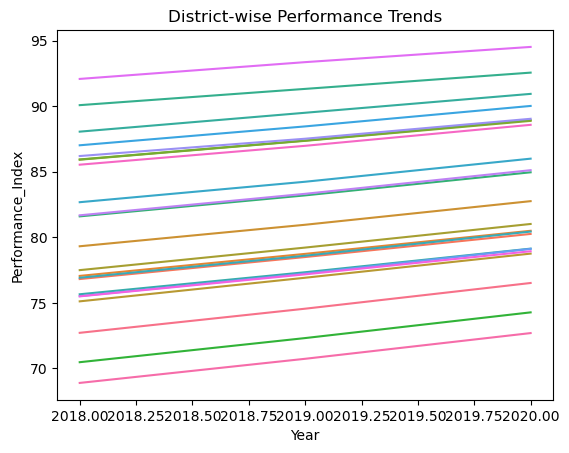

In [61]:
plt.figure()
sns.lineplot(data=df, x='Year', y='Performance_Index', hue='District', legend=False)
plt.title("District-wise Performance Trends")
plt.show()

#### Growth metrics help identify rapidly improving districts.

In [62]:
growth = df.groupby('District')['Madhyamik_Growth_%'].mean().sort_values(ascending=False).head(5)
growth

District
JALPAIGURI           1.230581
UTTAR DINAJPUR       1.188458
ALIPURDUAR           1.158711
PASCHIM BARDHAMAN    1.061123
DAKSHIN DINAJPUR     1.055475
Name: Madhyamik_Growth_%, dtype: float64